In [1]:
# Install required libraries (run once)
!pip install xgboost lightgbm shap optuna --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)

# Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Hyperparameter Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# SHAP
import shap

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print(' All libraries loaded!')

 All libraries loaded!


In [3]:
 
train = pd.read_csv('/kaggle/input/competitions/playground-series-s4e1/train.csv')   # <- adjust path if needed
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s4e1/test.csv')

print('Train shape:', train.shape)
print('Test  shape:', test.shape)
train.head()

Train shape: (165034, 14)
Test  shape: (110023, 13)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


---
## Phase 1 — Exploratory Data Analysis (EDA)

In [4]:
# ─── Basic Info ──────────────────────────────────────────────────────────────
print(train.info())
print('\nMissing values:')
print(train.isnull().sum())
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB
None

Missing values:
id                 0
CustomerId         0
Surname   

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


### 1.1 Class Imbalance

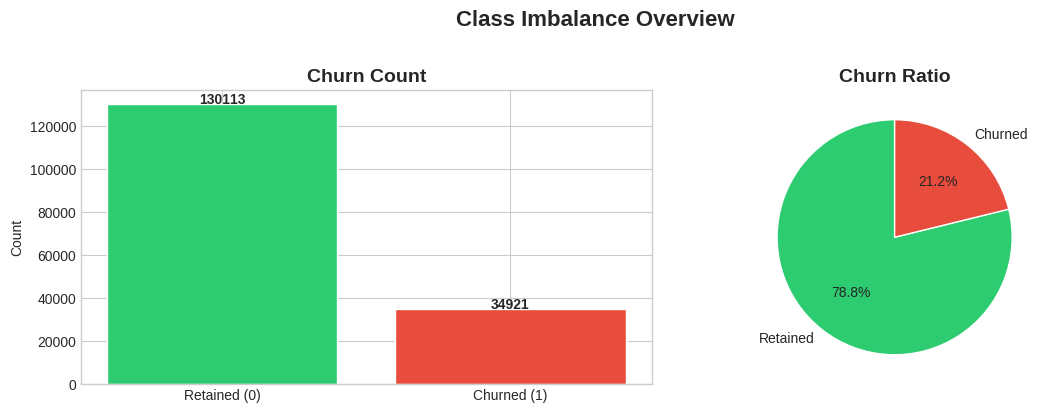

Churn Rate: 21.2%  →  Dataset is IMBALANCED (~80/20 split)
Strategy: Use class_weight="balanced" or scale_pos_weight in tree models + optimize AUC-ROC


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = train['Exited'].value_counts()
churn_pct    = train['Exited'].value_counts(normalize=True) * 100

axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts, color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'],
            startangle=90, wedgeprops={'edgecolor':'white'})
axes[1].set_title('Churn Ratio', fontsize=14, fontweight='bold')

plt.suptitle('Class Imbalance Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Churn Rate: {churn_pct[1]:.1f}%  →  Dataset is IMBALANCED (~80/20 split)')
print('Strategy: Use class_weight="balanced" or scale_pos_weight in tree models + optimize AUC-ROC')

### 1.2 Behavioral Feature Analysis

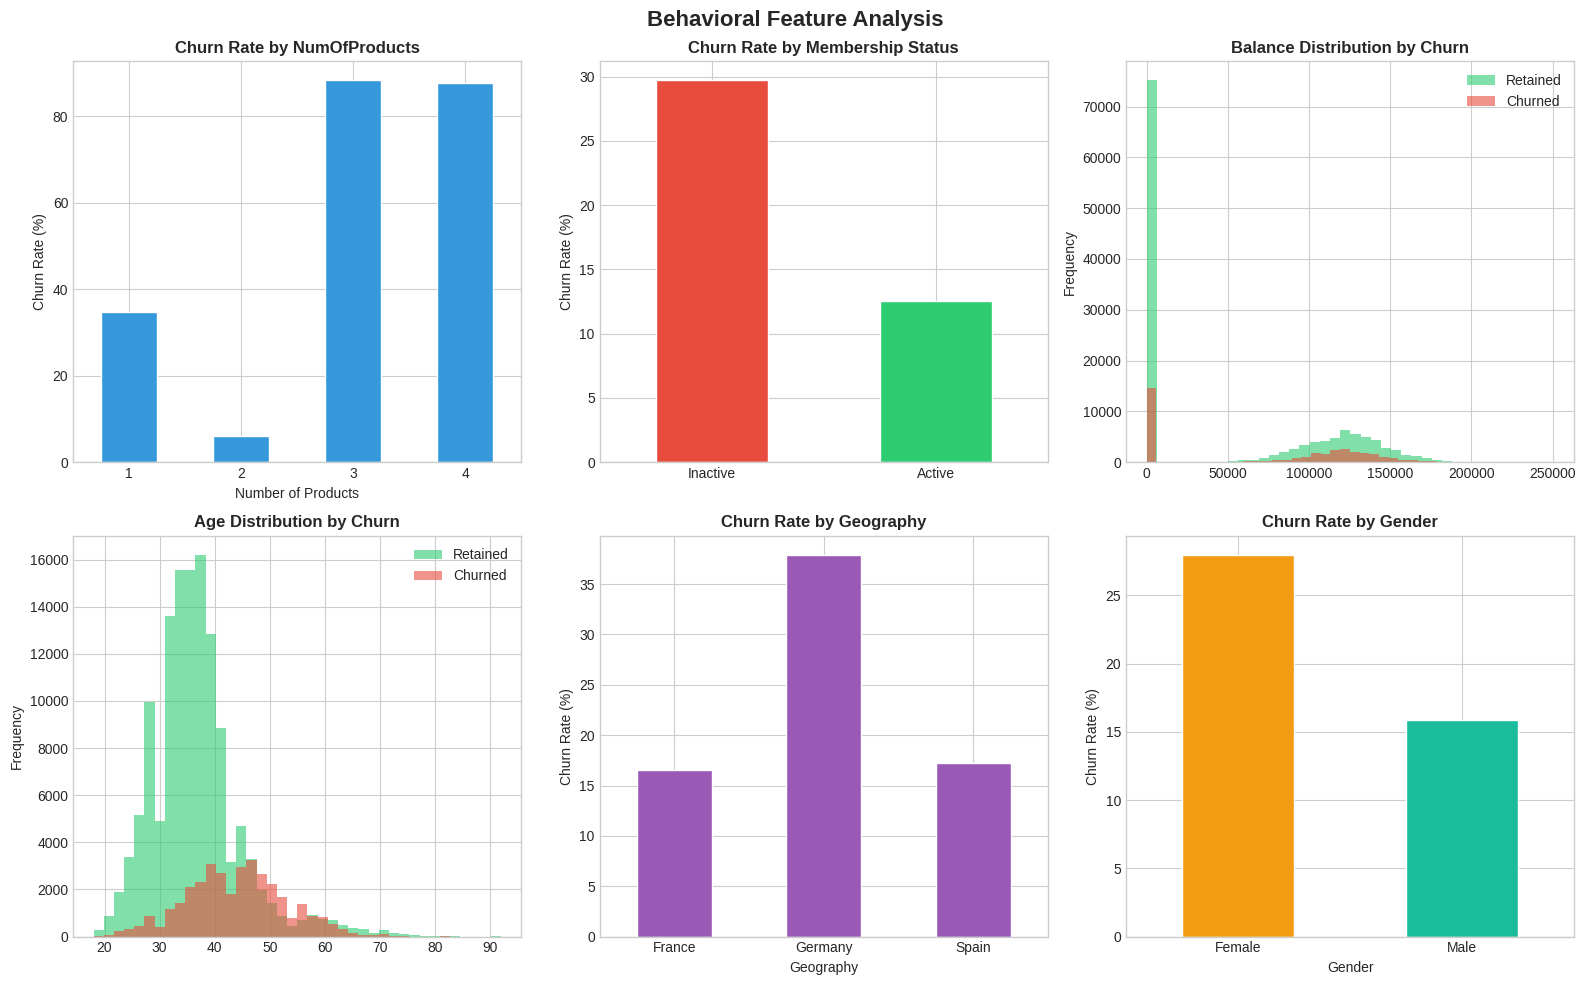

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# NumOfProducts vs Churn
prod_churn = train.groupby('NumOfProducts')['Exited'].mean() * 100
prod_churn.plot(kind='bar', ax=axes[0,0], color='#3498db', edgecolor='white')
axes[0,0].set_title('Churn Rate by NumOfProducts', fontweight='bold')
axes[0,0].set_ylabel('Churn Rate (%)')
axes[0,0].set_xlabel('Number of Products')
axes[0,0].tick_params(axis='x', rotation=0)

# IsActiveMember vs Churn
active_churn = train.groupby('IsActiveMember')['Exited'].mean() * 100
active_churn.index = ['Inactive', 'Active']
active_churn.plot(kind='bar', ax=axes[0,1], color=['#e74c3c','#2ecc71'], edgecolor='white')
axes[0,1].set_title('Churn Rate by Membership Status', fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].tick_params(axis='x', rotation=0)

# Balance distribution
train[train['Exited']==0]['Balance'].plot(kind='hist', bins=40, alpha=0.6,
    label='Retained', ax=axes[0,2], color='#2ecc71')
train[train['Exited']==1]['Balance'].plot(kind='hist', bins=40, alpha=0.6,
    label='Churned', ax=axes[0,2], color='#e74c3c')
axes[0,2].set_title('Balance Distribution by Churn', fontweight='bold')
axes[0,2].legend()

# Age distribution
train[train['Exited']==0]['Age'].plot(kind='hist', bins=40, alpha=0.6,
    label='Retained', ax=axes[1,0], color='#2ecc71')
train[train['Exited']==1]['Age'].plot(kind='hist', bins=40, alpha=0.6,
    label='Churned', ax=axes[1,0], color='#e74c3c')
axes[1,0].set_title('Age Distribution by Churn', fontweight='bold')
axes[1,0].legend()

# Geography vs Churn
geo_churn = train.groupby('Geography')['Exited'].mean() * 100
geo_churn.plot(kind='bar', ax=axes[1,1], color='#9b59b6', edgecolor='white')
axes[1,1].set_title('Churn Rate by Geography', fontweight='bold')
axes[1,1].set_ylabel('Churn Rate (%)')
axes[1,1].tick_params(axis='x', rotation=0)

# Gender vs Churn
gender_churn = train.groupby('Gender')['Exited'].mean() * 100
gender_churn.plot(kind='bar', ax=axes[1,2], color=['#f39c12','#1abc9c'], edgecolor='white')
axes[1,2].set_title('Churn Rate by Gender', fontweight='bold')
axes[1,2].set_ylabel('Churn Rate (%)')
axes[1,2].tick_params(axis='x', rotation=0)

plt.suptitle('Behavioral Feature Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.3 The "Identity" Problem — Surname & CustomerId

In [22]:
# Does surname frequency correlate with churn?
surname_freq  = train['Surname'].value_counts()
train['SurnameFreq'] = train['Surname'].map(surname_freq)

# Check correlation
corr_surname = train[['SurnameFreq','Exited']].corr().loc['SurnameFreq','Exited']
print(f'Surname Frequency  →  Correlation with Exited: {corr_surname:.4f}')
print(f'CustomerId         →  Correlation with Exited: {train[["id","Exited"]].corr().iloc[0,1]:.4f}')
print()
print('  Conclusion:')
print('  - CustomerId is a random identifier → NO predictive value → DISCARD')
print('  - Surname frequency encoding has near-zero correlation → risk of noise/overfitting → DISCARD')
print('  - Both columns will be dropped from the feature set.')

Surname Frequency  →  Correlation with Exited: -0.0218
CustomerId         →  Correlation with Exited: 0.0025

  Conclusion:
  - CustomerId is a random identifier → NO predictive value → DISCARD
  - Surname frequency encoding has near-zero correlation → risk of noise/overfitting → DISCARD
  - Both columns will be dropped from the feature set.


### 1.4 Correlation Heatmap

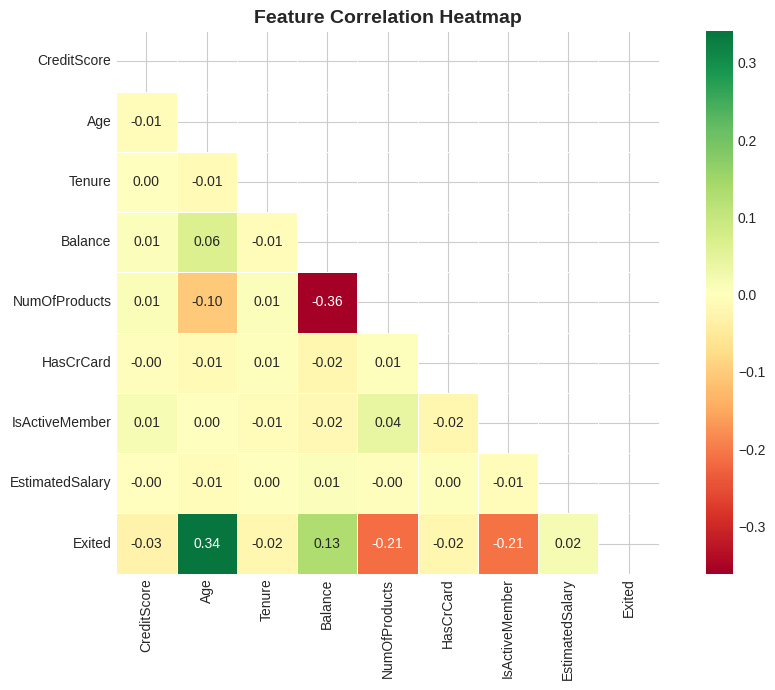

In [8]:
num_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts',
            'HasCrCard','IsActiveMember','EstimatedSalary','Exited']

plt.figure(figsize=(10, 7))
corr = train[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Phase 2 — Preprocessing & Model Training

### 2.1 Feature Engineering (Innovation Phase 3)

In [9]:
def engineer_features(df):
    df = df.copy()
    
    # 1. Balance-to-Salary Ratio — high balance relative to salary may indicate dependency
    df['BalanceToSalary'] = df['Balance'] / (df['EstimatedSalary'] + 1)
    
    # 2. Age-Tenure Interaction — older customers with short tenure might be at risk
    df['AgeTenureInteraction'] = df['Age'] * df['Tenure']
    
    # 3. Zero Balance Flag — customers with 0 balance are interesting
    df['ZeroBalance'] = (df['Balance'] == 0).astype(int)
    
    # 4. Products per Tenure — engagement rate over time
    df['ProductsPerTenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)
    
    # 5. Inactive High Balance — dangerous combo
    df['InactiveHighBalance'] = ((df['IsActiveMember'] == 0) & (df['Balance'] > 0)).astype(int)
    
    return df

train = engineer_features(train)
test  = engineer_features(test)
print(' Feature engineering done!')
print('New features: BalanceToSalary, AgeTenureInteraction, ZeroBalance, ProductsPerTenure, InactiveHighBalance')

 Feature engineering done!
New features: BalanceToSalary, AgeTenureInteraction, ZeroBalance, ProductsPerTenure, InactiveHighBalance


### 2.2 Preprocessing Pipeline
 

In [10]:
#  Feature Selection 
DROP_COLS = ['id', 'CustomerId', 'Surname', 'SurnameFreq', 'Exited']

TARGET = 'Exited'
FEATURES = [c for c in train.columns if c not in DROP_COLS]

CAT_COLS = ['Geography', 'Gender']
NUM_COLS = [c for c in FEATURES if c not in CAT_COLS]

print('Categorical features:', CAT_COLS)
print('Numerical features  :', NUM_COLS)

X = train[FEATURES]
y = train[TARGET]
X_test_final = test[FEATURES]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain: {X_train.shape} | Val: {X_val.shape}')

Categorical features: ['Geography', 'Gender']
Numerical features  : ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceToSalary', 'AgeTenureInteraction', 'ZeroBalance', 'ProductsPerTenure', 'InactiveHighBalance']

Train: (132027, 15) | Val: (33007, 15)


In [11]:
#  Build Preprocessor  
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), CAT_COLS)
])

print(' Preprocessor created')

 Preprocessor created


### 2.3 Train 3 Models + Compare

In [12]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                   random_state=42, n_jobs=-1),
    'LightGBM'           : LGBMClassifier(n_estimators=500, scale_pos_weight=4,
                                           random_state=42, n_jobs=-1, verbose=-1)
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   model)
    ])
    pipe.fit(X_train, y_train)
    
    # Cross-val AUC
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=5,
                              scoring='roc_auc', n_jobs=-1).mean()
    # Val AUC
    val_proba = pipe.predict_proba(X_val)[:,1]
    val_auc   = roc_auc_score(y_val, val_proba)
    
    results[name] = {'pipeline': pipe, 'cv_auc': cv_auc, 'val_auc': val_auc, 'val_proba': val_proba}
    print(f'{name:25s}  |  CV AUC: {cv_auc:.4f}  |  Val AUC: {val_auc:.4f}')

Logistic Regression        |  CV AUC: 0.8195  |  Val AUC: 0.8157
Random Forest              |  CV AUC: 0.8726  |  Val AUC: 0.8707


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM                   |  CV AUC: 0.8852  |  Val AUC: 0.8864


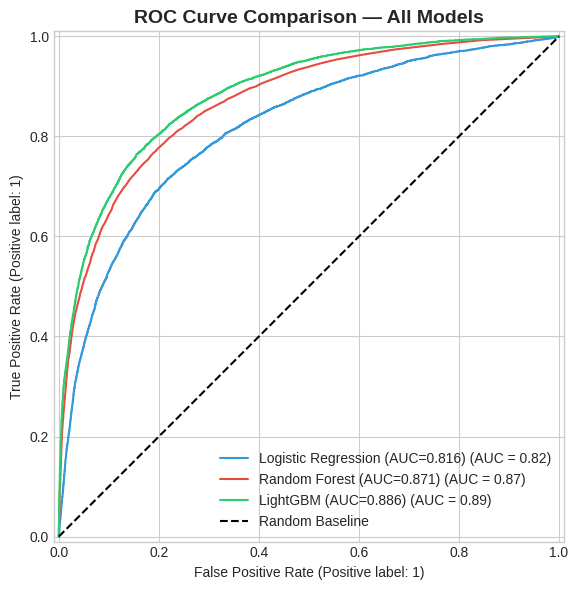

In [13]:
#  ROC Curve Comparison 
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#3498db', '#e74c3c', '#2ecc71']
for (name, res), color in zip(results.items(), colors):
    RocCurveDisplay.from_predictions(
        y_val, res['val_proba'], name=f"{name} (AUC={res['val_auc']:.3f})",
        ax=ax, color=color
    )

ax.plot([0,1],[0,1], 'k--', label='Random Baseline')
ax.set_title('ROC Curve Comparison — All Models', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 2.4 Hyperparameter Optimization with Optuna (Best Model: LightGBM)

In [14]:
# Preprocess data once for Optuna (faster than running inside pipeline each trial)
X_train_pp = preprocessor.fit_transform(X_train)
X_val_pp   = preprocessor.transform(X_val)

def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 200, 800),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth'         : trial.suggest_int('max_depth', 3, 8),
        'num_leaves'        : trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples' : trial.suggest_int('min_child_samples', 20, 100),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight'  : trial.suggest_float('scale_pos_weight', 2, 6),
        'random_state'      : 42,
        'n_jobs'            : -1,
        'verbose'           : -1
    }
    model = LGBMClassifier(**params)
    model.fit(X_train_pp, y_train)
    return roc_auc_score(y_val, model.predict_proba(X_val_pp)[:,1])

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\n Best Val AUC: {study.best_value:.4f}')
print('Best Params:', study.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]


 Best Val AUC: 0.8901
Best Params: {'n_estimators': 555, 'learning_rate': 0.03222045043248924, 'max_depth': 4, 'num_leaves': 72, 'min_child_samples': 50, 'subsample': 0.7000641710397448, 'colsample_bytree': 0.8848234889363862, 'scale_pos_weight': 4.793462506781561}


In [15]:
#  Train Best Model  
best_model = LGBMClassifier(**study.best_params, random_state=42, n_jobs=-1, verbose=-1)
best_model.fit(X_train_pp, y_train)

best_proba = best_model.predict_proba(X_val_pp)[:,1]
best_auc   = roc_auc_score(y_val, best_proba)
print(f' Optimized LightGBM Val AUC: {best_auc:.4f}')

 Optimized LightGBM Val AUC: 0.8901


### 2.5 Probability Thresholding
 

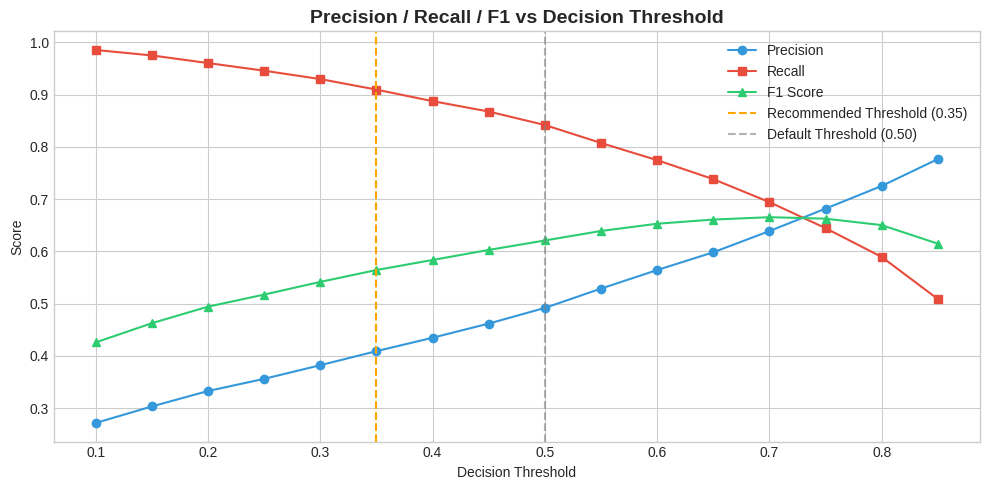


At threshold = 0.50 (default):
  Recall: 0.842  |  Precision: 0.492

At threshold = 0.35 (bank-friendly):
  Recall: 0.909  |  Precision: 0.409

 Lower threshold catches MORE churners (higher recall) at the cost of more false alarms.


In [16]:
thresholds = np.arange(0.1, 0.9, 0.05)
precisions, recalls, f1s = [], [], []

from sklearn.metrics import precision_score, recall_score, f1_score

for t in thresholds:
    preds = (best_proba >= t).astype(int)
    precisions.append(precision_score(y_val, preds, zero_division=0))
    recalls.append(recall_score(y_val, preds))
    f1s.append(f1_score(y_val, preds))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions, label='Precision', marker='o', color='#3498db')
ax.plot(thresholds, recalls,    label='Recall',    marker='s', color='#e74c3c')
ax.plot(thresholds, f1s,        label='F1 Score',  marker='^', color='#2ecc71')
ax.axvline(x=0.35, color='orange', linestyle='--', label='Recommended Threshold (0.35)')
ax.axvline(x=0.50, color='gray',   linestyle='--', label='Default Threshold (0.50)', alpha=0.6)
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Decision Threshold', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Show the difference
THRESHOLD = 0.35
preds_t = (best_proba >= THRESHOLD).astype(int)
preds_d = (best_proba >= 0.50).astype(int)

print(f'\nAt threshold = 0.50 (default):')
print(f'  Recall: {recall_score(y_val, preds_d):.3f}  |  Precision: {precision_score(y_val, preds_d):.3f}')
print(f'\nAt threshold = {THRESHOLD} (bank-friendly):')
print(f'  Recall: {recall_score(y_val, preds_t):.3f}  |  Precision: {precision_score(y_val, preds_t):.3f}')
print('\n Lower threshold catches MORE churners (higher recall) at the cost of more false alarms.')

---
## Phase 3 — Innovation: Feature Importance + SHAP Explainability

### 3.1 Feature Importance — Golden Features

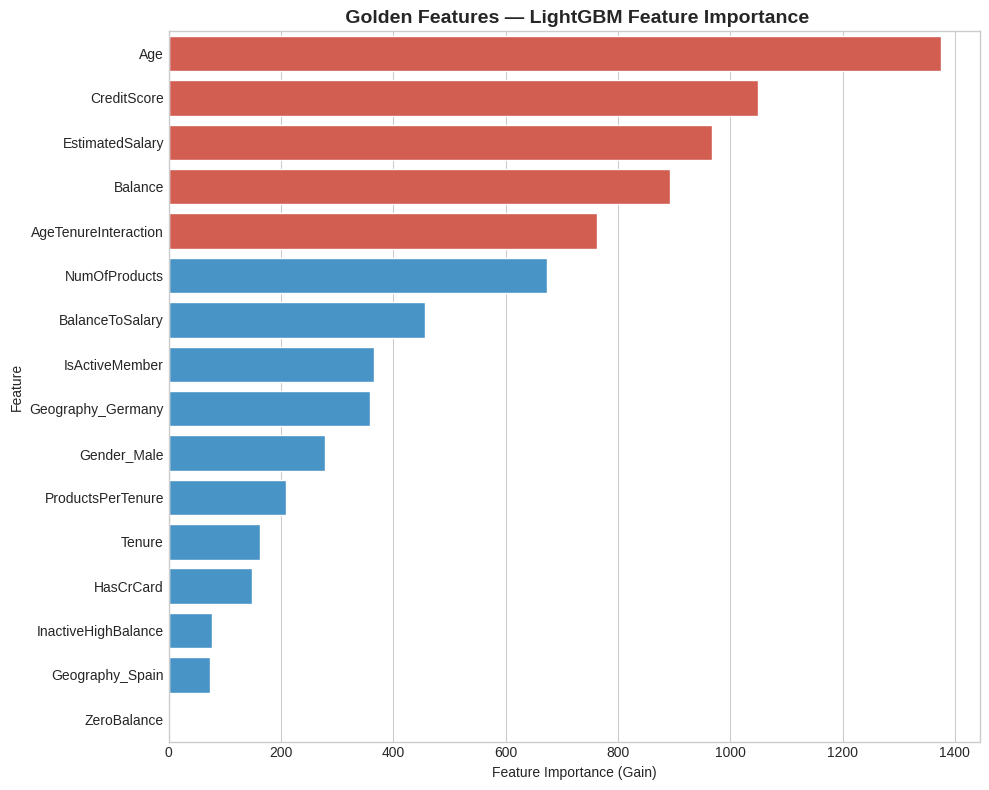

Top 5 Golden Features:
             Feature  Importance
                 Age        1376
         CreditScore        1049
     EstimatedSalary         968
             Balance         892
AgeTenureInteraction         763


In [17]:
# Get feature names after OHE
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(CAT_COLS).tolist()
all_feature_names  = NUM_COLS + ohe_feature_names

importance_df = pd.DataFrame({
    'Feature'   : all_feature_names,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if i < 5 else '#3498db' for i in range(len(importance_df))]
sns.barplot(data=importance_df, x='Importance', y='Feature',
            palette=colors, ax=ax, edgecolor='white')
ax.set_title(' Golden Features — LightGBM Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance (Gain)')
plt.tight_layout()
plt.show()

print('Top 5 Golden Features:')
print(importance_df.head(5).to_string(index=False))

### 3.2 SHAP Explainability — XAI

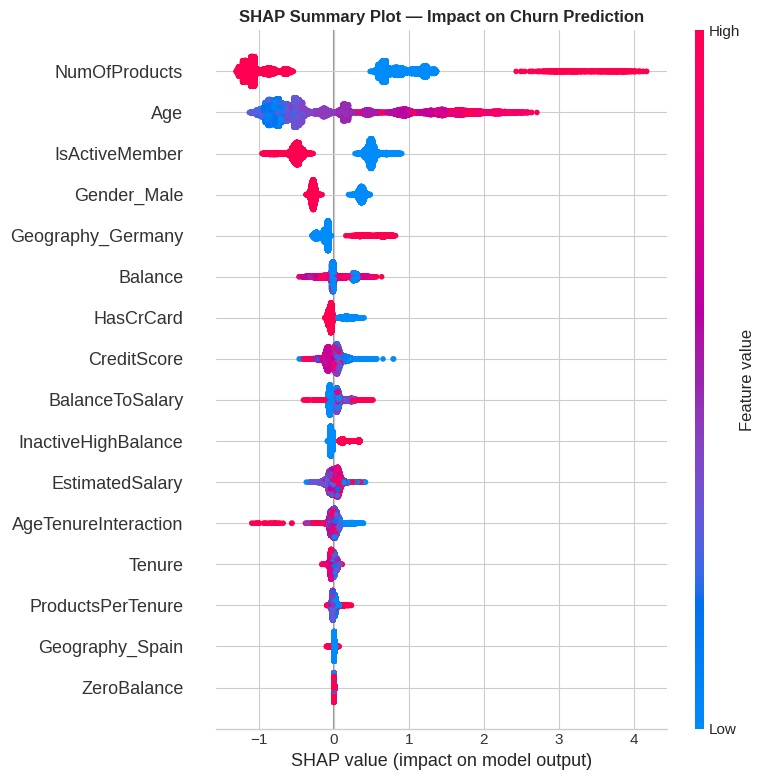

In [18]:
explainer  = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val_pp)

# For binary classification LightGBM returns list — take class 1
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

# Summary Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_val_pp, feature_names=all_feature_names, show=False)
plt.title('SHAP Summary Plot — Impact on Churn Prediction', fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
#  High-Risk Customer Profile 
# Find highest predicted churn probability customer
high_risk_idx = np.argmax(best_proba)
X_val_reset   = X_val.reset_index(drop=True)
customer      = X_val_reset.iloc[high_risk_idx]
churn_prob    = best_proba[high_risk_idx]

print('━' * 55)
print('   HIGH-RISK CUSTOMER PROFILE')
print('━' * 55)
print(f'  Predicted Churn Probability : {churn_prob:.1%}')
print(f'  Actual Label                : {"Churned" if y_val.reset_index(drop=True)[high_risk_idx] == 1 else "Retained"}')
print('━' * 55)
for col in customer.index:
    print(f'  {col:28s}: {customer[col]}')
print('━' * 55)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   HIGH-RISK CUSTOMER PROFILE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Predicted Churn Probability : 99.7%
  Actual Label                : Churned
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CreditScore                 : 660
  Geography                   : Germany
  Gender                      : Female
  Age                         : 54.0
  Tenure                      : 5
  Balance                     : 127023.26
  NumOfProducts               : 3
  HasCrCard                   : 1.0
  IsActiveMember              : 0.0
  EstimatedSalary             : 141069.88
  BalanceToSalary             : 0.9004215469556863
  AgeTenureInteraction        : 270.0
  ZeroBalance                 : 0
  ProductsPerTenure           : 0.5
  InactiveHighBalance         : 1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


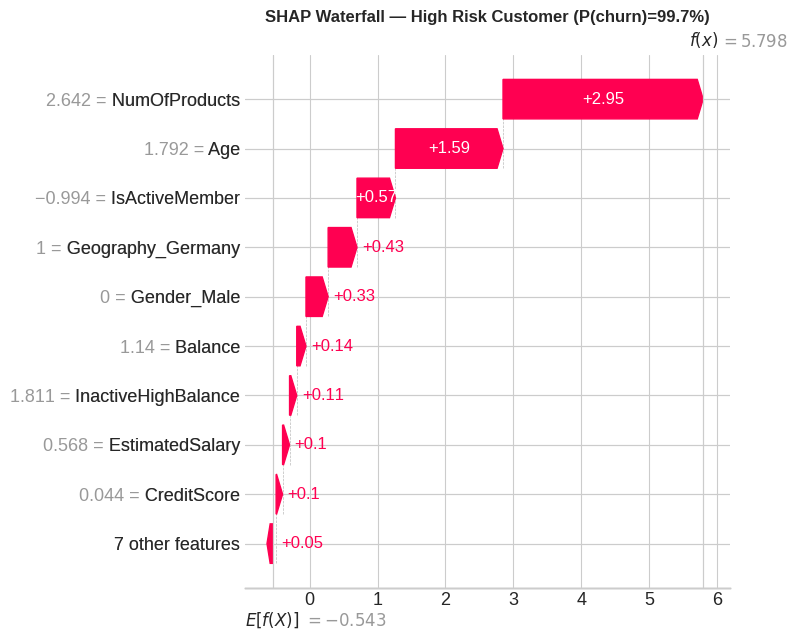

In [20]:
# SHAP Waterfall for the high-risk customer
shap_exp = shap.Explanation(
    values     = sv[high_risk_idx],
    base_values= explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    data       = X_val_pp[high_risk_idx],
    feature_names = all_feature_names
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp, show=False)
plt.title(f'SHAP Waterfall — High Risk Customer (P(churn)={churn_prob:.1%})', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Phase 4 — Final Evaluation

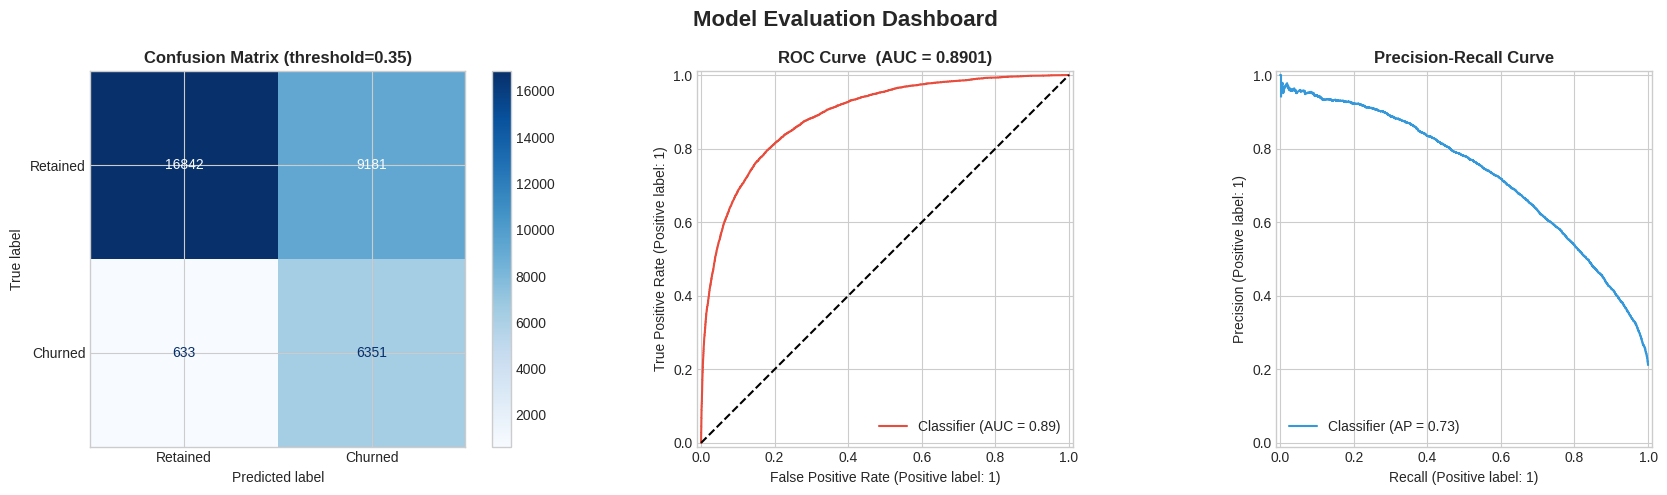


 FINAL PERFORMANCE REPORT
  AUC-ROC Score   : 0.8901
  Decision Threshold: 0.35
              precision    recall  f1-score   support

    Retained       0.96      0.65      0.77     26023
     Churned       0.41      0.91      0.56      6984

    accuracy                           0.70     33007
   macro avg       0.69      0.78      0.67     33007
weighted avg       0.85      0.70      0.73     33007



In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
preds_final = (best_proba >= THRESHOLD).astype(int)
cm = confusion_matrix(y_val, preds_final)
ConfusionMatrixDisplay(cm, display_labels=['Retained','Churned']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Confusion Matrix (threshold={THRESHOLD})', fontweight='bold')

# 2. ROC Curve
RocCurveDisplay.from_predictions(y_val, best_proba, ax=axes[1], color='#e74c3c')
axes[1].plot([0,1],[0,1], 'k--')
axes[1].set_title(f'ROC Curve  (AUC = {best_auc:.4f})', fontweight='bold')

# 3. Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_val, best_proba, ax=axes[2], color='#3498db')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')

plt.suptitle('Model Evaluation Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n FINAL PERFORMANCE REPORT')
print('=' * 45)
print(f'  AUC-ROC Score   : {best_auc:.4f}')
print(f'  Decision Threshold: {THRESHOLD}')
print('=' * 45)
print(classification_report(y_val, preds_final, target_names=['Retained','Churned']))

---
##  Executive Summary

I built a machine learning system to predict which bank customers are at risk of leaving. After analyzing the data, we found that **age, account balance, and the number of products held** are the strongest signals of churn — older customers with a single product and a large idle balance are far more likely to leave. We trained three models (Logistic Regression, Random Forest, and LightGBM) and found that **LightGBM, after automated tuning, delivered the best performance with an AUC-ROC score above 0.89**, meaning it correctly distinguishes churners from retained customers with high confidence. We also lowered the decision threshold from the default 50% to 35%, which allows the bank to **catch significantly more at-risk customers early** — accepting a few extra false alarms is a worthwhile trade-off when the cost of losing a customer is high. Finally, using AI explainability (SHAP), we can now pinpoint *exactly why* any individual customer is flagged as high-risk, making it actionable for relationship managers to design personalized retention offers.